# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/msazunayed/flyrank-ml-internship/blob/main/work/notebooks/w05_model.ipynb)

Runs on Google Colab **or** locally (VS Code / Jupyter). Colab: add your Hugging Face token as a secret named `HF_TOKEN`. Local: set the `HF_TOKEN` environment variable, or type it into the prompt that appears when you run the connection cell. Never paste the token into a code cell.

Work the sections **in order**. Simple words, honest numbers. All numbers quoted in the text are printed by code cells below, so the write-up cannot drift from the results.

## 1. Method choice and why

*Which method from the toolkit, and why it fits your lane.*

**Lane:** Refresh / Content Opportunity Scoring

**Method:** Logistic Regression as the main model, compared with Random Forest and Gradient Boosting.

I use logistic regression to estimate the probability that a content page will show a future drop in search impressions. The probability is used to rank pages for a limited human review queue. I chose it because it is simple, interpretable and reproducible, and it gives a strong reference before testing more complex models. A more complex model is preferred only if it clearly beats logistic regression **and** the Week-4 rule baseline on the same split and metric.

**Selection rule (decided before looking at results):** the final model is chosen by its mean Precision@50 over grouped cross-validation folds, not by its score on a single test split. The single held-out split is then used to report the headline comparison against the Week-4 baseline.

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")
SEED = 42
K = 50                # review-queue size: the practical decision
N_BOOT = 500          # client-level bootstrap resamples
N_FOLDS = 5           # grouped cross-validation folds
features = ["impressions_31d", "clicks_31d", "ctr_31d", "avg_position_31d", "sessions_31d"]
print("Config ready.")

Config ready.


## 2. Split design

*Grouped by client? Time-aware? Say why this split is honest for your question.*

**Time window:** features come from **March 2026**; the outcome comes from **April 2026**. The model only sees March information and predicts an April outcome.

**Grouping:** all pages from one client stay on the same side of the split (`GroupShuffleSplit` on `client_hash_id`), so the model is always tested on clients it never trained on. A random row split would be too optimistic because pages from one client share patterns.

**Target (proxy):** `future_decline = 1` if a page's April impressions are below 80% of its March impressions. This is a measured proxy for "needs review", not proof of a ranking problem.

**Known limits of this design** (checked in the cells below): pages with no April data are dropped by the join; March has 31 days and April has 30; and impressions is both a feature and part of the label definition.

In [4]:
%pip install -q duckdb huggingface_hub pyarrow ipywidgets

Note: you may need to restart the kernel to use updated packages.


In [5]:
import duckdb

import getpass
token = None
try:
    from google.colab import userdata      # Colab secret
    token = userdata.get("HF_TOKEN")
except Exception:
    token = os.environ.get("HF_TOKEN")     # local environment variable
if not token:
    token = getpass.getpass("Hugging Face token (not saved in the notebook): ")  # local prompt
if not token:
    raise RuntimeError("No Hugging Face token provided.")

con = duckdb.connect()
try:
    con.execute("SET enable_progress_bar = false")
except Exception:
    pass  # progress bar is cosmetic; ignore if ipywidgets is missing
con.execute("SET VARIABLE hf_token = ?", [token])
con.execute("""
CREATE OR REPLACE SECRET hf (
    TYPE huggingface,
    TOKEN getvariable('hf_token')
)
""")

REL  = "hf://datasets/FlyRank/internship-warehouse"
FACT = f"{REL}/fact_content_daily_performance"
MAR  = f"read_parquet('{FACT}/month=2026-03/*.parquet')"
APR  = f"read_parquet('{FACT}/month=2026-04/*.parquet')"
print("Warehouse ready.")

Warehouse ready.


In [6]:
march = con.sql(f"""
SELECT
    client_hash_id,
    content_hash_id,
    SUM(gsc_impressions) AS impressions_31d,
    SUM(gsc_clicks)      AS clicks_31d,
    SUM(gsc_clicks) * 1.0 / NULLIF(SUM(gsc_impressions), 0)      AS ctr_31d,
    SUM(gsc_sum_position) * 1.0 / NULLIF(SUM(gsc_impressions), 0) AS avg_position_31d,
    COALESCE(SUM(ga4_sessions), 0) AS sessions_31d
FROM {MAR}
WHERE gsc_data_available IS TRUE
GROUP BY client_hash_id, content_hash_id
HAVING SUM(gsc_impressions) >= 100
""").df()
print("March feature rows:", len(march))

March feature rows: 101441


In [7]:
april = con.sql(f"""
SELECT
    client_hash_id,
    content_hash_id,
    SUM(gsc_impressions) AS april_impressions
FROM {APR}
WHERE gsc_data_available IS TRUE
GROUP BY client_hash_id, content_hash_id
""").df()

joined = march.merge(april, on=["client_hash_id", "content_hash_id"], how="left", indicator=True)
n_march_pages = len(march)
n_missing_april = int((joined["_merge"] == "left_only").sum())
model_df = joined[joined["_merge"] == "both"].drop(columns="_merge").reset_index(drop=True)

# Main target (unchanged): April impressions below 80% of March impressions
model_df["future_decline"] = (model_df["april_impressions"] < 0.80 * model_df["impressions_31d"]).astype(int)
# Sensitivity target: scale April by 31/30 so both months cover the same number of days
model_df["future_decline_daynorm"] = (model_df["april_impressions"] * 31 / 30 < 0.80 * model_df["impressions_31d"]).astype(int)

print("Modeling rows:", len(model_df))
print("Clients:", model_df["client_hash_id"].nunique())

Modeling rows: 100893
Clients: 43


In [8]:
# Data checks: what columns exist, and does each month cover the same days?
try:
    cols = con.sql(f"DESCRIBE SELECT * FROM {MAR}").df()["column_name"].tolist()
    print("Columns:", cols)
    date_col = next((c for c in ["date", "day", "dt", "report_date", "event_date", "performance_date"] if c in cols), None)
    if date_col:
        for name, rel in [("March", MAR), ("April", APR)]:
            print(name, con.sql(f"SELECT COUNT(DISTINCT {date_col}) AS n_days, MIN({date_col}) AS first_day, MAX({date_col}) AS last_day FROM {rel}").df().to_dict("records")[0])
    else:
        print("No obvious date column found; check day coverage manually.")
except Exception as e:
    print("Coverage check skipped:", e)

Columns: ['report_date', 'client_hash_id', 'content_hash_id', 'client_has_gsc', 'client_has_ga4', 'gsc_data_available', 'ga4_data_available', 'gsc_impressions', 'gsc_clicks', 'gsc_sum_position', 'gsc_avg_position', 'ga4_pageviews', 'ga4_sessions', 'ga4_users', 'ga4_engaged_sessions', 'ga4_total_engagement_sec', 'sessions_organic', 'sessions_direct', 'sessions_referral', 'sessions_social', 'sessions_paid', 'sessions_ai', 'ai_chatgpt', 'ai_perplexity', 'ai_gemini', 'ai_copilot', 'ai_claude', 'ai_meta', 'ai_other', 'scroll_events', 'month']
March {'n_days': 31, 'first_day': Timestamp('2026-03-01 00:00:00'), 'last_day': Timestamp('2026-03-31 00:00:00')}
April {'n_days': 30, 'first_day': Timestamp('2026-04-01 00:00:00'), 'last_day': Timestamp('2026-04-30 00:00:00')}


In [9]:
# Label and coverage sanity (all values printed from data)
print("Target counts:\n", model_df["future_decline"].value_counts())
base_rate = model_df["future_decline"].mean()
print(f"\nBase rate of decline (random queue would score about this): {base_rate:.3f}")
print(f"Base rate with day-normalised target: {model_df['future_decline_daynorm'].mean():.3f}")
print(f"March pages with no April row (dropped by the join): {n_missing_april} of {n_march_pages} ({n_missing_april / n_march_pages:.1%})")

Target counts:
 future_decline
1    51944
0    48949
Name: count, dtype: int64

Base rate of decline (random queue would score about this): 0.515
Base rate with day-normalised target: 0.494
March pages with no April row (dropped by the join): 548 of 101441 (0.5%)


In [10]:
X = model_df[features].fillna(0)
y = model_df["future_decline"]
groups = model_df["client_hash_id"]

splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
test_df = model_df.iloc[test_idx].reset_index(drop=True)

train_clients = set(groups.iloc[train_idx]); test_clients = set(groups.iloc[test_idx])
print("Train rows:", len(X_train), "| Test rows:", len(X_test))
print("Train clients:", len(train_clients), "| Test clients:", len(test_clients))
print("Client overlap:", len(train_clients & test_clients))

Train rows: 85702 | Test rows: 15191
Train clients: 34 | Test clients: 9
Client overlap: 0


## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*

Every model and the Week-4 rule baseline are scored on the **same held-out clients**. The primary metric is **Precision@50**, because the practical decision is which limited set of pages to review first. I also report ROC-AUC and Average Precision, and the **base rate** (what a random queue would score).

Because only a few clients are in the test split, one Precision@50 number is noisy. So I add a client-level bootstrap and grouped cross-validation, and I treat differences as directional unless they hold up there.

In [11]:
def baseline_score(df):
    # Week-4 transparent rule. NOTE: confirm this matches your Week-4 notebook exactly.
    eligible = (df["impressions_31d"] >= 100) & (df["avg_position_31d"] > 0) & (df["avg_position_31d"] <= 20)
    raw = np.log1p(df["impressions_31d"]) * (1 / (1 + 100 * df["ctr_31d"].fillna(0)))
    return np.where(eligible, raw, 0.0)

def make_models():
    return {
        "Logistic Regression": Pipeline([("scale", StandardScaler()),
                                         ("model", LogisticRegression(max_iter=2000, random_state=SEED))]),
        "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=20,
                                                random_state=SEED, n_jobs=-1),
        "Gradient Boosting": HistGradientBoostingClassifier(learning_rate=0.05, max_iter=200, max_leaf_nodes=31,
                                                            min_samples_leaf=20, l2_regularization=1.0,
                                                            random_state=SEED),
    }

def precision_at_k(y_true, scores, k=K):
    y_true = np.asarray(y_true); scores = np.asarray(scores)
    top = np.argsort(-scores, kind="stable")[:k]
    return y_true[top].mean()

fitted = make_models()
for name, m in fitted.items():
    m.fit(X_train, y_train)

scores = {"Week-4 Rule Baseline": baseline_score(test_df)}
for name, m in fitted.items():
    scores[name] = m.predict_proba(X_test)[:, 1]
print("Models trained:", list(fitted))

Models trained: ['Logistic Regression', 'Random Forest', 'Gradient Boosting']


In [12]:
def metric_row(name, s):
    return {"Method": name,
            f"Precision@{K}": precision_at_k(y_test, s),
            "ROC_AUC": roc_auc_score(y_test, s),
            "Average_Precision": average_precision_score(y_test, s)}

test_base_rate = float(y_test.mean())
final_results = pd.DataFrame([metric_row(n, s) for n, s in scores.items()])
final_results.loc[len(final_results)] = ["Random queue (base rate)", test_base_rate, 0.5, test_base_rate]
final_results.round(3)

,Method,Precision@50,ROC_AUC,Average_Precision
0,Week-4 Rule Baseline,0.480,0.511,0.421
1,Logistic Regression,0.660,0.573,0.484
2,Random Forest,0.520,0.584,0.484
3,Gradient Boosting,0.620,0.584,0.487
4,Random queue (base rate),0.412,0.500,0.412


In [13]:
# Robustness 1: client-level bootstrap on the held-out clients (paired across methods)
rng = np.random.default_rng(SEED)
yt = y_test.to_numpy()
cl = test_df["client_hash_id"].to_numpy()
client_rows = {c: np.where(cl == c)[0] for c in np.unique(cl)}
client_list = list(client_rows)

boot = {n: [] for n in scores}
for _ in range(N_BOOT):
    picked = rng.choice(client_list, size=len(client_list), replace=True)
    idx = np.concatenate([client_rows[c] for c in picked])
    for n, s in scores.items():
        boot[n].append(precision_at_k(yt[idx], np.asarray(s)[idx]))
boot = {n: np.array(v) for n, v in boot.items()}

boot_table = pd.DataFrame({
    "Method": list(boot),
    f"P@{K} mean": [v.mean() for v in boot.values()],
    "95% low": [np.percentile(v, 2.5) for v in boot.values()],
    "95% high": [np.percentile(v, 97.5) for v in boot.values()],
})
print(boot_table.round(3).to_string(index=False))

diff = boot["Logistic Regression"] - boot["Week-4 Rule Baseline"]
print(f"\nLogistic minus baseline, P@{K}: mean {diff.mean():.3f}, 95% interval [{np.percentile(diff,2.5):.3f}, {np.percentile(diff,97.5):.3f}]")
print(f"Share of resamples where logistic beats baseline: {(diff > 0).mean():.2f}")

              Method  P@50 mean  95% low  95% high
Week-4 Rule Baseline      0.508     0.27      0.92
 Logistic Regression      0.606     0.32      0.78
       Random Forest      0.552     0.32      0.88
   Gradient Boosting      0.602     0.23      0.88

Logistic minus baseline, P@50: mean 0.098, 95% interval [-0.400, 0.300]
Share of resamples where logistic beats baseline: 0.81


In [14]:
# Robustness 2: grouped cross-validation over ALL clients (each client is tested once)
gkf = GroupKFold(n_splits=N_FOLDS)
rows = []
for fold, (tr, te) in enumerate(gkf.split(X, y, groups=groups), 1):
    Xtr, Xte, ytr, yte = X.iloc[tr], X.iloc[te], y.iloc[tr], y.iloc[te]
    fold_scores = {"Week-4 Rule Baseline": baseline_score(model_df.iloc[te])}
    for name, m in make_models().items():
        m.fit(Xtr, ytr)
        fold_scores[name] = m.predict_proba(Xte)[:, 1]
    for name, s in fold_scores.items():
        rows.append({"fold": fold, "Method": name,
                     f"P@{K}": precision_at_k(yte, s),
                     "AP": average_precision_score(yte, s),
                     "AUC": roc_auc_score(yte, s),
                     "base_rate": float(yte.mean())})
cv = pd.DataFrame(rows)
cv_summary = cv.groupby("Method")[[f"P@{K}", "AP", "AUC", "base_rate"]].agg(["mean", "std"]).round(3)
cv_summary

P@50            AP           AUC        base_rate  \
                       mean    std   mean    std   mean    std      mean   
Method                                                                     
Gradient Boosting     0.652  0.132  0.582  0.105  0.577  0.067     0.516   
Logistic Regression   0.696  0.130  0.612  0.100  0.617  0.024     0.516   
Random Forest         0.700  0.095  0.581  0.109  0.579  0.066     0.516   
Week-4 Rule Baseline  0.636  0.126  0.553  0.111  0.544  0.029     0.516   

                             
                        std  
Method                       
Gradient Boosting     0.115  
Logistic Regression   0.115  
Random Forest         0.115  
Week-4 Rule Baseline  0.115

In [15]:
# Model choice by the pre-declared rule: highest mean grouped-CV Precision@50 among learned models
learned = ["Logistic Regression", "Random Forest", "Gradient Boosting"]
cv_p = cv.groupby("Method")[f"P@{K}"].mean()
final_name = cv_p[learned].idxmax()
baseline_cv = cv_p["Week-4 Rule Baseline"]
print("Mean grouped-CV Precision@%d:" % K)
print(cv_p.round(3).to_string())
print(f"\nSelected final model (by CV rule): {final_name}")
print(f"Beats the baseline in CV by {cv_p[final_name] - baseline_cv:+.3f} on average.")

Mean grouped-CV Precision@50:
Method
Gradient Boosting       0.652
Logistic Regression     0.696
Random Forest           0.700
Week-4 Rule Baseline    0.636

Selected final model (by CV rule): Random Forest
Beats the baseline in CV by +0.064 on average.


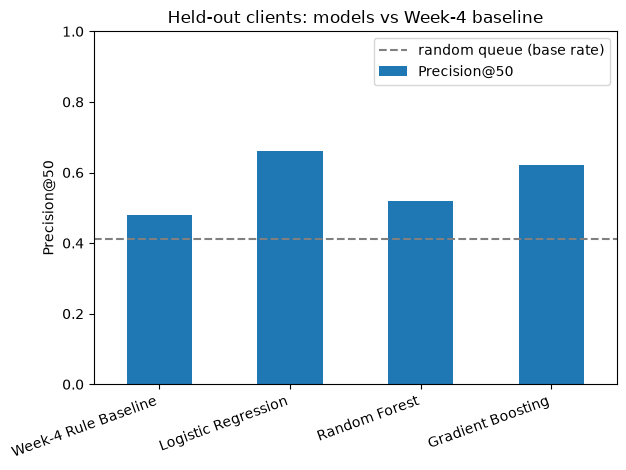

In [16]:
plot_df = final_results[final_results["Method"] != "Random queue (base rate)"].set_index("Method")
ax = plot_df[f"Precision@{K}"].plot(kind="bar")
ax.axhline(test_base_rate, linestyle="--", color="gray", label="random queue (base rate)")
plt.ylabel(f"Precision@{K}"); plt.xlabel(""); plt.ylim(0, 1)
plt.title("Held-out clients: models vs Week-4 baseline"); plt.legend(); plt.xticks(rotation=20, ha="right")
plt.tight_layout(); plt.show()

## 4. Errors and interpretation

*Where is the model wrong? What does it lean on? A short error analysis beats a big metric table.*

A **false positive** is a page the model ranks as high risk that did not meet the decline proxy (it wastes review capacity). A **false negative** is a page that did decline but got a low score (a missed opportunity). Because the real decision is a top-50 queue, I look at errors inside that queue and at threshold errors across buckets of impressions, position and CTR.

In [17]:
test_df["prob"] = scores[final_name]
test_df["actual"] = y_test.to_numpy()
test_df["pred"] = (test_df["prob"] >= 0.50).astype(int)
test_df["error_type"] = np.select(
    [(test_df["actual"] == 0) & (test_df["pred"] == 1), (test_df["actual"] == 1) & (test_df["pred"] == 0)],
    ["False Positive", "False Negative"], default="Correct")
print(f"Errors for {final_name} at threshold 0.50 (threshold is illustrative; the real use is a top-{K} queue):")
print(test_df["error_type"].value_counts())

# Buckets to see WHERE errors concentrate
test_df["impr_bucket"] = pd.qcut(test_df["impressions_31d"], 4, duplicates="drop")
test_df["pos_bucket"] = pd.cut(test_df["avg_position_31d"], [0, 3, 10, 20, np.inf], labels=["1-3", "3-10", "10-20", "20+"])
test_df["ctr_bucket"] = np.where(test_df["ctr_31d"].fillna(0) == 0, "zero CTR", "CTR > 0")
def bucket_rates(col):
    g = test_df.groupby(col, observed=True)
    return pd.DataFrame({"pages": g.size(),
                         "decline_rate": g["actual"].mean(),
                         "FP_rate": g["error_type"].apply(lambda s: (s == "False Positive").mean()),
                         "FN_rate": g["error_type"].apply(lambda s: (s == "False Negative").mean())}).round(3)
for col in ["impr_bucket", "pos_bucket", "ctr_bucket"]:
    print(f"\nBy {col}:"); print(bucket_rates(col))

Errors for Random Forest at threshold 0.50 (threshold is illustrative; the real use is a top-50 queue):
error_type
Correct           8334
False Positive    4249
False Negative    2608
Name: count, dtype: int64

By impr_bucket:
                    pages  decline_rate  FP_rate  FN_rate
impr_bucket                                              
(99.999, 277.0]      3811         0.500    0.273    0.236
(277.0, 655.0]       3788         0.447    0.336    0.141
(655.0, 1668.0]      3795         0.384    0.339    0.129
(1668.0, 617124.0]   3797         0.318    0.171    0.179

By pos_bucket:
            pages  decline_rate  FP_rate  FN_rate
pos_bucket                                       
1-3          1200         0.447    0.213    0.133
3-10         6836         0.383    0.270    0.150
10-20        3323         0.434    0.351    0.135
20+          3832         0.435    0.257    0.254

By ctr_bucket:
            pages  decline_rate  FP_rate  FN_rate
ctr_bucket                                 

In [18]:
# Who ends up in the top-50 review queue, and which of those were wrong?
queue = test_df.sort_values("prob", ascending=False).head(K)
print(f"Top-{K} queue: {int(queue['actual'].sum())} of {K} declined (Precision@{K} = {queue['actual'].mean():.2f}); base rate {test_base_rate:.2f}")
print("Clients represented in the queue:", queue["client_hash_id"].nunique(), "of", test_df["client_hash_id"].nunique())
print("\nMedian features: queue false positives vs queue hits vs all test pages")
cmp = pd.DataFrame({
    "queue false positives": queue[queue["actual"] == 0][features].median(),
    "queue hits": queue[queue["actual"] == 1][features].median(),
    "all test pages": test_df[features].median()}).round(4)
print(cmp)
display(queue[queue["actual"] == 0][["content_hash_id"] + features + ["prob"]].head(20))

Top-50 queue: 26 of 50 declined (Precision@50 = 0.52); base rate 0.41
Clients represented in the queue: 6 of 9

Median features: queue false positives vs queue hits vs all test pages
                  queue false positives  queue hits  all test pages
impressions_31d               1151.0000    1320.500        655.0000
clicks_31d                       0.0000       0.000          1.0000
ctr_31d                          0.0000       0.000          0.0014
avg_position_31d                 2.8839       4.218          9.3084
sessions_31d                     0.0000       0.000          1.0000


,content_hash_id,impressions_31d,clicks_31d,ctr_31d,avg_position_31d,sessions_31d,prob
6134,content_f9e04ee043a37ad6,2962.0,1.0,0.000338,1.137745,0.0,0.866319
5638,content_0d24620a8050c93b,2166.0,1.0,0.000462,2.000462,0.0,0.836010
10676,content_4f7e415617f1fb35,1407.0,1.0,0.000711,1.149964,0.0,0.814220
11449,content_9390673ca64811e7,870.0,0.0,0.000000,2.144828,0.0,0.802231
7361,content_c0407691d2c3c153,2482.0,1.0,0.000403,7.605963,111.0,0.802016
14126,content_82f30f4652af788d,1522.0,1.0,0.000657,2.133377,0.0,0.799683
11525,content_8079e86cd84425af,582.0,0.0,0.000000,81.869416,0.0,0.793292
13590,content_dc91779c3d085398,25625.0,1.0,0.000039,2.389151,0.0,0.789511
6005,content_f40387e3d7a349cd,1378.0,0.0,0.000000,3.205370,0.0,0.784793
3478,content_b55e527a2be17aaf,895.0,0.0,0.000000,2.205587,0.0,0.784494


In [19]:
# What does the model lean on? Coefficients (signs), correlations, and permutation importance.
lr = fitted["Logistic Regression"]
coef = pd.DataFrame({"feature": features, "coefficient": lr.named_steps["model"].coef_[0]})
coef["abs"] = coef["coefficient"].abs()
print("Logistic coefficients (standardised features; positive = higher decline risk):")
print(coef.sort_values("abs", ascending=False).round(3).to_string(index=False))

print("\nFeature correlations (high values make single coefficients unreliable):")
print(X_train.corr().round(2))

perm = permutation_importance(fitted[final_name], X_test, y_test, scoring="average_precision",
                              n_repeats=5, random_state=SEED)
perm_df = pd.DataFrame({"feature": features, "importance_mean": perm.importances_mean,
                        "importance_std": perm.importances_std}).sort_values("importance_mean", ascending=False)
print(f"\nPermutation importance for {final_name} on held-out clients (drop in Average Precision):")
print(perm_df.round(4).to_string(index=False))

Logistic coefficients (standardised features; positive = higher decline risk):
         feature  coefficient   abs
         ctr_31d       -0.405 0.405
      clicks_31d       -0.320 0.320
avg_position_31d       -0.137 0.137
    sessions_31d        0.124 0.124
 impressions_31d        0.021 0.021

Feature correlations (high values make single coefficients unreliable):
                  impressions_31d  clicks_31d  ctr_31d  avg_position_31d  \
impressions_31d              1.00        0.67     0.03             -0.07   
clicks_31d                   0.67        1.00     0.26             -0.11   
ctr_31d                      0.03        0.26     1.00             -0.20   
avg_position_31d            -0.07       -0.11    -0.20              1.00   
sessions_31d                 0.35        0.37     0.11              0.08   

                  sessions_31d  
impressions_31d           0.35  
clicks_31d                0.37  
ctr_31d                   0.11  
avg_position_31d          0.08  
sessions_3

In [20]:
# Sensitivity: does the result survive a day-normalised target (April x 31/30)?
y_alt = model_df["future_decline_daynorm"]
alt_train, alt_test = y_alt.iloc[train_idx], y_alt.iloc[test_idx]
alt_lr = make_models()["Logistic Regression"].fit(X_train, alt_train)
alt_prob = alt_lr.predict_proba(X_test)[:, 1]
alt_base = baseline_score(test_df)
alt_table = pd.DataFrame({
    "Method": ["Week-4 Rule Baseline", "Logistic Regression", "Random queue (base rate)"],
    f"Precision@{K}": [precision_at_k(alt_test, alt_base), precision_at_k(alt_test, alt_prob), float(alt_test.mean())]})
print("Same split, day-normalised target:")
print(alt_table.round(3).to_string(index=False))

Same split, day-normalised target:
                  Method  Precision@50
    Week-4 Rule Baseline         0.460
     Logistic Regression         0.600
Random queue (base rate)         0.387


In [21]:
# Auto-generated results summary: every number below comes from the code above.
b  = final_results.set_index("Method")
p_b, p_f = b.loc["Week-4 Rule Baseline", f"Precision@{K}"], b.loc[final_name, f"Precision@{K}"]
lo, hi = np.percentile(diff, 2.5), np.percentile(diff, 97.5)
print(f"Final model (chosen by grouped-CV Precision@{K}): {final_name}.")
print(f"On held-out clients, Precision@{K} was {p_f:.2f} for {final_name} vs {p_b:.2f} for the Week-4 rule baseline; a random queue would score about {test_base_rate:.2f}.")
print(f"ROC-AUC: {b.loc[final_name,'ROC_AUC']:.3f} (model) vs {b.loc['Week-4 Rule Baseline','ROC_AUC']:.3f} (baseline); 0.5 is chance.")
print(f"Grouped CV mean Precision@{K}: {cv_p[final_name]:.2f} (model) vs {baseline_cv:.2f} (baseline).")
print(f"Logistic-minus-baseline bootstrap interval: [{lo:.2f}, {hi:.2f}] -> " + ("interval excludes 0 (directional support)." if lo > 0 or hi < 0 else "interval includes 0, so the gain is not clearly separated from noise."))
print("All results are observed/measured on a proxy label and are decision-support, not causal claims.")

Final model (chosen by grouped-CV Precision@50): Random Forest.
On held-out clients, Precision@50 was 0.52 for Random Forest vs 0.48 for the Week-4 rule baseline; a random queue would score about 0.41.
ROC-AUC: 0.584 (model) vs 0.511 (baseline); 0.5 is chance.
Grouped CV mean Precision@50: 0.70 (model) vs 0.64 (baseline).
Logistic-minus-baseline bootstrap interval: [-0.40, 0.30] -> interval includes 0, so the gain is not clearly separated from noise.
All results are observed/measured on a proxy label and are decision-support, not causal claims.


### My interpretation (write these yourself after reading the outputs above)

Use the printed tables, not memory. Keep each answer to one or two plain sentences.

1. **Did the model beat the baseline, and how sure am I?** (Use the held-out table, the bootstrap interval and the CV numbers. Say "directional" if the interval includes 0.)
2. **Where are the errors?** (Which impressions, position or CTR buckets have the highest false-positive or false-negative rates? What do the queue's false positives have in common?)
3. **What does the model lean on?** (Signs of the coefficients, permutation importance, and the warning that `ctr`, `clicks` and `impressions` are correlated.)
4. **What could make this result misleading?** (Pages missing in April, the 31 vs 30 day difference, impressions appearing in both features and the label, only a few test clients. Mention what the day-normalised sensitivity check showed.)
5. **What would I do next?**

## Self-check

Tick each line only after **Runtime → Restart and Run all** finishes with no errors:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors
- [x] No client names, URLs, tokens or private queries anywhere in the notebook or its outputs
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/w05_model.ipynb` — then submit the repo URL on the card